# Customer data — exploration and cleaning

Brief step 6a and 6b: explore and analyse the data, then clean and pre-process it.

Dataset: `data/marketing_campaign.csv` (2240 customers, 29 columns).

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")

# This copy of the file is padded with spaces, so we clean the column names
# and the text values, and convert Income back to a proper number.
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
df["Income"] = pd.to_numeric(df["Income"], errors="coerce")

print("Shape:", df.shape)
df.head()

Shape: (2240, 29)


C:\Users\User\AppData\Local\Temp\ipykernel_20944\3951171767.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## 1. First look at the data

In [9]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,2240.0,5592.159821,3246.662198,0.0,2828.25,5458.5,8427.75,11191.0
Year_Birth,2240.0,1968.805804,11.984069,1893.0,1959.00,1970.0,1977.00,1996.0
Income,2216.0,52247.251354,25173.076661,1730.0,35303.00,51381.5,68522.00,666666.0
Kidhome,2240.0,0.444196,0.538398,0.0,0.00,0.0,1.00,2.0
Teenhome,2240.0,0.506250,0.544538,0.0,0.00,0.0,1.00,2.0
Recency,2240.0,49.109375,28.962453,0.0,24.00,49.0,74.00,99.0
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0


## 2. Missing values

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print()
print("Percentage of rows affected:",
      round(100 * df.isnull().any(axis=1).sum() / len(df), 2), "%")

Columns with missing values:
Income    24
dtype: int64

Percentage of rows affected: 1.07 %


Only `Income` has missing values, on a small share of the rows. We drop those
rows: they are few, and imputing an income would invent information that could
distort the clusters.

In [12]:
df = df.dropna()
print("Shape after dropping rows with missing income:", df.shape)

Shape after dropping rows with missing income: (2216, 29)


## 3. Feature engineering

The raw columns are hard to interpret directly. We build a few clearer features:

- `Age` from `Year_Birth`
- `Customer_Days` — how long the person has been a customer
- `Total_Spending` — sum of all product categories
- `Total_Purchases` — sum of all purchase channels
- `Children` — kids plus teenagers at home
- `Family_Size` — from marital status and children
- `Education_Level` and `Living_With` — simplified categories

In [13]:
# Reference date: the day after the last recorded enrolment.
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
reference_date = df["Dt_Customer"].max()

df["Age"] = 2014 - df["Year_Birth"]
df["Customer_Days"] = (reference_date - df["Dt_Customer"]).dt.days

spending_cols = ["MntWines", "MntFruits", "MntMeatProducts",
                 "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[spending_cols].sum(axis=1)

purchase_cols = ["NumDealsPurchases", "NumWebPurchases",
                 "NumCatalogPurchases", "NumStorePurchases"]
df["Total_Purchases"] = df[purchase_cols].sum(axis=1)

df["Children"] = df["Kidhome"] + df["Teenhome"]

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Absurd": "Alone", "Widow": "Alone", "YOLO": "Alone",
    "Divorced": "Alone", "Single": "Alone", "Alone": "Alone",
})

df["Family_Size"] = df["Living_With"].replace({"Alone": 1, "Partner": 2}) + df["Children"]

df["Is_Parent"] = (df["Children"] > 0).astype(int)

df["Education_Level"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate", "Master": "Postgraduate", "PhD": "Postgraduate",
})

df[["Age", "Customer_Days", "Total_Spending", "Total_Purchases",
    "Children", "Family_Size", "Is_Parent", "Education_Level", "Living_With"]].head()

,Age,Customer_Days,Total_Spending,Total_Purchases,Children,Family_Size,Is_Parent,Education_Level,Living_With
0,57,663,1617,25,0,1,0,Graduate,Alone
1,60,113,27,6,2,3,1,Graduate,Alone
2,49,312,776,21,0,2,0,Graduate,Partner
3,30,139,53,8,1,3,1,Graduate,Partner
4,33,161,422,19,1,3,1,Postgraduate,Partner


## 4. Distributions and outliers

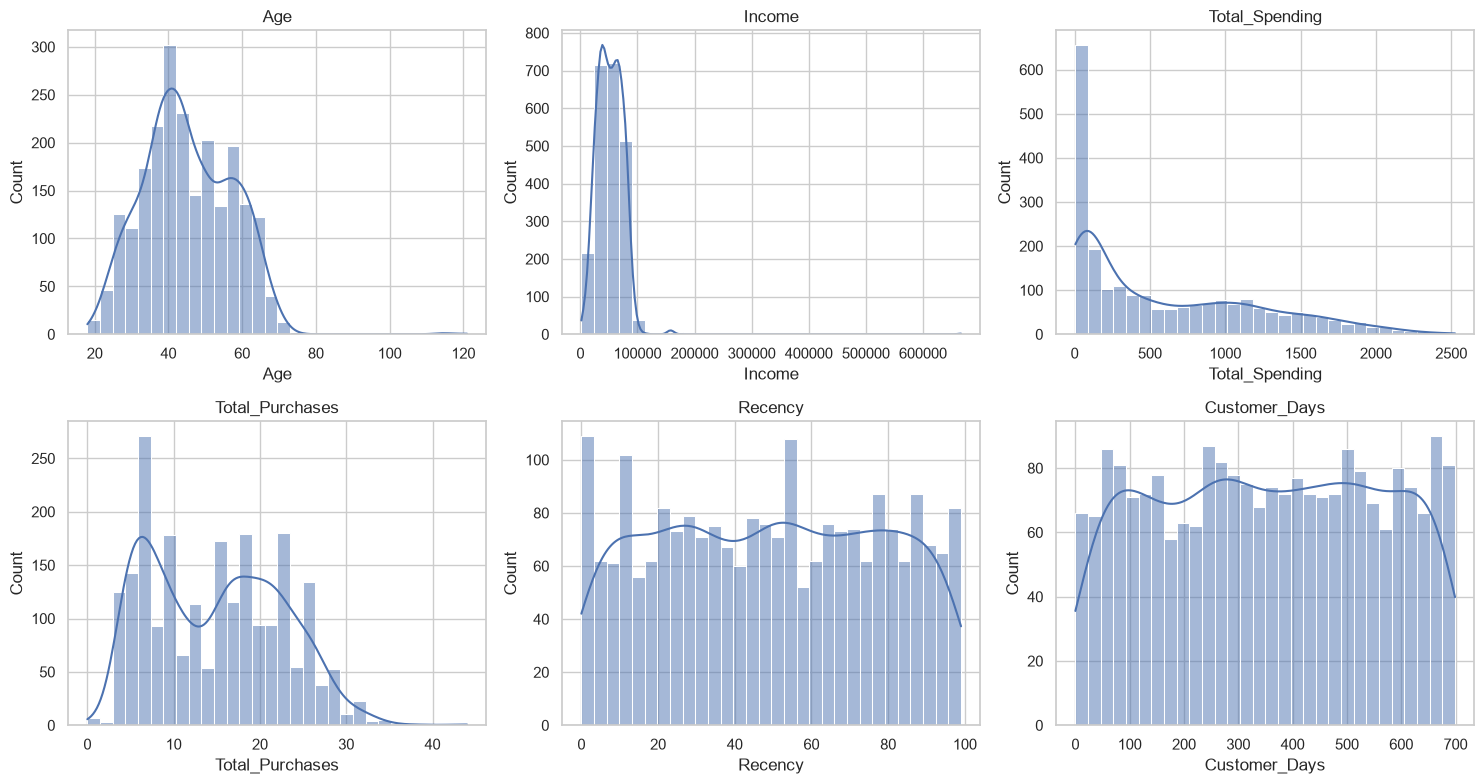

In [14]:
numeric_to_plot = ["Age", "Income", "Total_Spending", "Total_Purchases",
                   "Recency", "Customer_Days"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), numeric_to_plot):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()

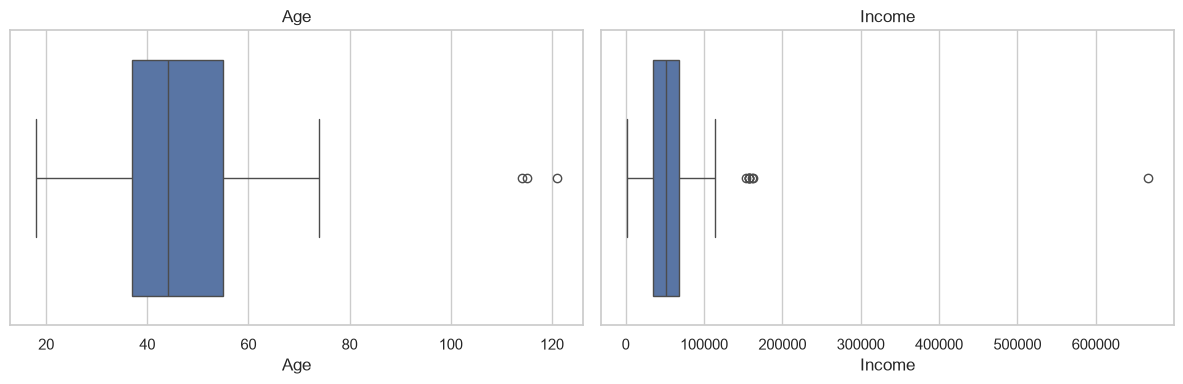

Customers older than 100: 3
Customers with income above 200000: 1


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x=df["Age"], ax=axes[0]);    axes[0].set_title("Age")
sns.boxplot(x=df["Income"], ax=axes[1]); axes[1].set_title("Income")
plt.tight_layout()
plt.show()

print("Customers older than 100:", (df["Age"] > 100).sum())
print("Customers with income above 200000:", (df["Income"] > 200000).sum())

The boxplots show a few impossible ages (birth years in the 1890s) and one
extreme income. These are almost certainly data entry errors, and K-means is
very sensitive to outliers because centroids are means. We remove them.

In [16]:
before = df.shape[0]
df = df[df["Age"] < 100]
df = df[df["Income"] < 200000]
print(f"Removed {before - df.shape[0]} outlier rows. New shape: {df.shape}")

Removed 4 outlier rows. New shape: (2212, 38)


## 5. Relationships between variables

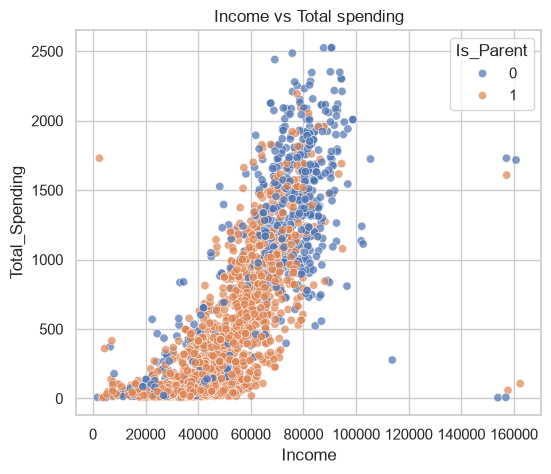

In [17]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="Income", y="Total_Spending", hue="Is_Parent", alpha=0.7)
plt.title("Income vs Total spending")
plt.show()

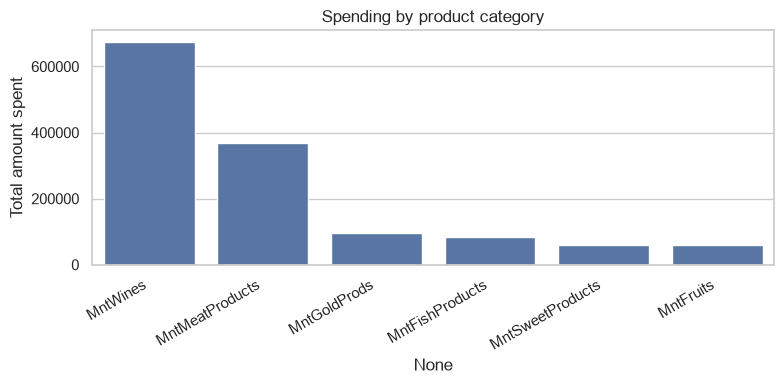

MntWines            675296
MntMeatProducts     369470
MntGoldProds         97164
MntFishProducts      83279
MntSweetProducts     59827
MntFruits            58241
dtype: int64

In [18]:
category_totals = df[spending_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x=category_totals.index, y=category_totals.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Total amount spent")
plt.title("Spending by product category")
plt.tight_layout()
plt.show()

category_totals

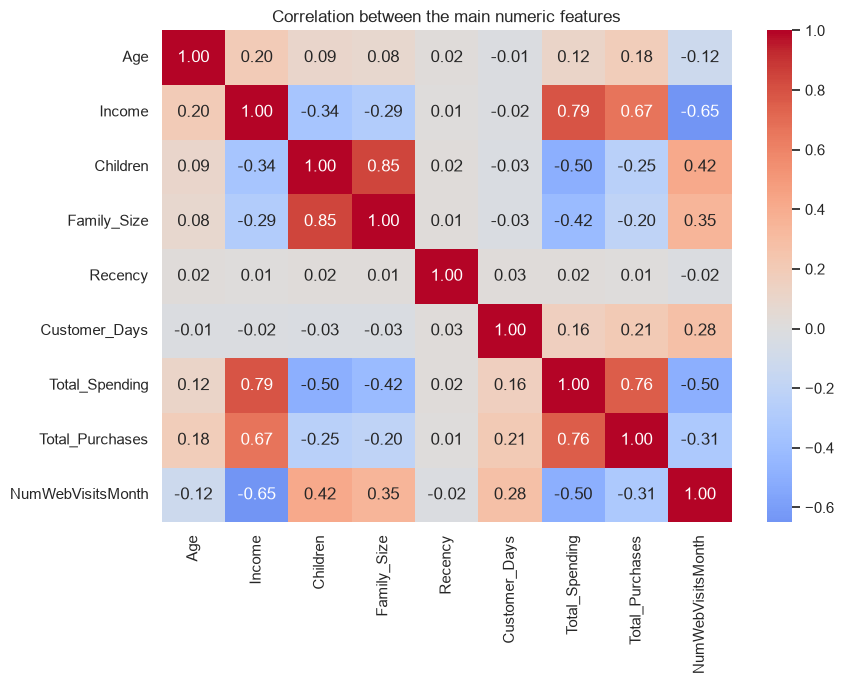

In [19]:
corr_cols = ["Age", "Income", "Children", "Family_Size", "Recency",
             "Customer_Days", "Total_Spending", "Total_Purchases",
             "NumWebVisitsMonth"]

plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between the main numeric features")
plt.tight_layout()
plt.show()

## 6. Drop useless columns and save the clean dataset

`Z_CostContact` and `Z_Revenue` are constant for every row, so they carry no
information. `ID`, `Year_Birth`, `Dt_Customer` and the original categorical
columns are replaced by the features we engineered.

In [20]:
print("Unique values in Z_CostContact:", df["Z_CostContact"].unique())
print("Unique values in Z_Revenue    :", df["Z_Revenue"].unique())

to_drop = ["ID", "Year_Birth", "Dt_Customer", "Z_CostContact", "Z_Revenue",
           "Marital_Status", "Education"]
df_clean = df.drop(columns=to_drop)

print("Shape of the clean dataset:", df_clean.shape)
df_clean.head()

Unique values in Z_CostContact: [3]
Unique values in Z_Revenue    : [11]
Shape of the clean dataset: (2212, 31)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Customer_Days,Total_Spending,Total_Purchases,Children,Living_With,Family_Size,Is_Parent,Education_Level
0,58138.0,0,0,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,57,663,1617,25,0,Alone,1,0,Graduate
1,46344.0,1,1,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,60,113,27,6,2,Alone,3,1,Graduate
2,71613.0,0,0,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,49,312,776,21,0,Partner,2,0,Graduate
3,26646.0,1,0,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,30,139,53,8,1,Partner,3,1,Graduate
4,58293.0,1,0,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,33,161,422,19,1,Partner,3,1,Postgraduate


In [21]:
df_clean.to_csv("../data/customers_clean.csv", index=False)
print("Saved to data/customers_clean.csv")

Saved to data/customers_clean.csv


## 7. Summary of the exploration

- The raw file has 2240 customers and 29 columns, separated by tabs.
- `Income` is the only column with missing values; those rows were dropped.
- Two columns (`Z_CostContact`, `Z_Revenue`) are constant and carry no information.
- A few rows had impossible ages and one extreme income; they were removed as
  data entry errors, which matters because K-means centroids are means and are
  therefore pulled by outliers.
- Income and total spending are strongly related, and the number of children is
  negatively related to spending.
- Wine and meat are by far the largest spending categories.
- Engineered features (`Age`, `Total_Spending`, `Family_Size`, ...) are easier to
  interpret than the raw columns, which will make the cluster profiling clearer.
- The clean dataset is saved to `data/customers_clean.csv` for the modelling notebook.